In [ ]:
from __future__ import print_function, division
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
import torch
#from test_bottleneck import *

torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False


class Conv_block(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(Conv_block, self).__init__()
        
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=True),
            nn.BatchNorm2d(out_ch),
            #nn.GroupNorm(16,out_ch),
            nn.Hardswish(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=True),
            nn.BatchNorm2d(out_ch),
            #nn.GroupNorm(16,out_ch),
            nn.Hardswish(inplace=True))
        self.conv_1x1_output = nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=1)

    def forward(self, x):

        y = self.conv(x)
        x = self.conv_1x1_output(x)
        return x+y


class Dense_layer(nn.Sequential):
    def __init__(self,in_ch,bottleneck_size,growth_rate):
    
        super(Dense_layer,self).__init__()
        
        self.add_module('norm1', nn.BatchNorm2d(in_ch)), # same with ..> norm1 = nn.BatchNorm2d(in_ch)
        self.add_module('relu1', nn.Hardswish(inplace=True)),
        self.add_module('conv1', nn.Conv2d(in_ch, bottleneck_size, kernel_size=1, stride=1, padding=0, bias=True)), #  512 ..> 128 channel
        self.add_module('norm2', nn.BatchNorm2d(bottleneck_size)),
        self.add_module('relu2', nn.Hardswish(inplace=True)),
        self.add_module('conv2', nn.Conv2d(bottleneck_size, growth_rate, kernel_size=3, stride=1, padding=1, bias=True)), # 128 ..> 32 channel

    def forward(self, x):
        new_features = super(Dense_layer, self).forward(x) # output --> (32 , h , w)
        return torch.cat([x, new_features], 1) # (512, h , w) + (32 ,  h ,w) ..> (544  , h , w)

class Dense_block(nn.Sequential):   # Dense_layer  inherits  nn.Sequential
        # self.Dense1=Dense_block(512,5,32)
        # self.Dense2=Dense_block(256,5,16)
            
    def __init__(self,in_channels,layer_counts,growth_rate):
        super(Dense_block,self).__init__()
        for i in range(layer_counts):
            bottleneck_size = 4 * growth_rate # growth rate 32 ..> 128 btl
            layer = Dense_layer(in_channels + i * growth_rate, bottleneck_size, growth_rate) # (512, 128 , 32) ..> (512+32 , 128 , 32) ..etc..>
            # layer output --> 
            self.add_module('denselayer%d' % (i + 1), layer) # dens layer 1 , 2 .. 5 ..> final layer 512 + 5*32 = 672 channels


# Dense block  → channels increase
# Transition   → channels compress

class TransitionLayer(nn.Sequential):
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()
        self.add_module('norm', nn.BatchNorm2d(in_channels))
        self.add_module('relu', nn.Hardswish(inplace=True))
        self.add_module('conv', nn.Conv2d(in_channels, out_channels,kernel_size=1, stride=1, bias=False))

class Conv_pooling(nn.Module):
    """
    # conv->pooling        #output_shape = (image_shape-filter_shape+2*padding)/stride + 1
    """
    def __init__(self, in_ch, out_ch): # 1 -> 32
        super().__init__()

        self.ConvPooling = nn.Sequential(
            #nn.Conv2d(in_ch, in_ch, kernel_size=2, stride=1, padding=1,dilation=2, bias=True),
            #nn.BatchNorm2d(in_ch),
            #nn.Hardswish(inplace=True),
            nn.Conv2d(in_ch, out_ch, kernel_size=2, stride=2, padding=0, bias=True),
            nn.BatchNorm2d(out_ch),
            nn.Hardswish(inplace=True)
        )

    def forward(self, x):
        out=self.ConvPooling(x)
        return out


class ASPP(nn.Module):
    
    def __init__(self, in_channel):
        super(ASPP,self).__init__()
          
        self.atrous_block1 = nn.Conv2d(in_channel, in_channel, kernel_size=1, stride=1)
        self.atrous_block2 = nn.Conv2d(in_channel, in_channel, kernel_size=3, stride=1, padding=2, dilation=2)
        self.atrous_block3 = nn.Conv2d(in_channel, in_channel, kernel_size=3, stride=1, padding=3, dilation=3)
        self.atrous_block4 = nn.Conv2d(in_channel, in_channel, kernel_size=3, stride=1, padding=4, dilation=4)
        self.conv_1x1_output = nn.Conv2d(in_channel * 4, in_channel, kernel_size=1, stride=1)


        self.ConvPooling = nn.Sequential(
            #effective_size=(k−1)⋅d+1=(2−1)⋅2+1=3

            nn.Conv2d(in_channel, in_channel*2, kernel_size=2, stride=1, padding=1, dilation=2, bias=True),
            nn.BatchNorm2d(in_channel*2),
            nn.Hardswish(inplace=True),
            #nn.Conv2d(in_channel, in_channel, kernel_size=2, stride=2, padding=0, bias=True),
            nn.MaxPool2d(2,stride=2),
            nn.BatchNorm2d(in_channel*2),
            nn.Hardswish(inplace=True)
        )

    def forward(self, x):
        atrous_block1 = self.atrous_block1(x)
        atrous_block2 = self.atrous_block2(x)
        atrous_block3 = self.atrous_block3(x)
        atrous_block4 = self.atrous_block4(x)
        out = self.conv_1x1_output(torch.cat([ atrous_block1, atrous_block2, atrous_block3, atrous_block4], dim=1))
        out = self.ConvPooling(out+x)
        return out

# class UpConv_block(nn.Module):
#     def __init__(self, in_ch, out_ch):
#         super(UpConv_block, self).__init__()
        
#         self.conv = nn.Sequential(
#             nn.Upsample(scale_factor=2, mode='bilinear'),
#             nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=True),
#             nn.BatchNorm2d(out_ch),
#             nn.Hardswish(inplace=True),
#             nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=True),
#             nn.BatchNorm2d(out_ch),
#             nn.Hardswish(inplace=True))

#     def forward(self, x):

#         y = self.conv(x)
        
#         return y

class CatConv_block(nn.Module):
    def __init__(self, in_ch, growth):
        super(CatConv_block, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_ch*growth, in_ch, kernel_size=1, stride=1),
            nn.BatchNorm2d(in_ch),
            nn.Hardswish(inplace=True))
        
        self.Up=nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear'),
            nn.BatchNorm2d(in_ch*2),
            nn.Hardswish(inplace=True),
            nn.Conv2d(in_ch*2, in_ch, kernel_size=1, stride=1),
            nn.BatchNorm2d(in_ch),
            nn.Hardswish(inplace=True))
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_ch*growth, in_ch*growth, kernel_size=3, stride=1, padding=1, bias=True),
            nn.BatchNorm2d(in_ch*growth),
            nn.Hardswish(inplace=True),
            nn.Conv2d(in_ch*growth, in_ch, kernel_size=1, stride=1),
            nn.BatchNorm2d(in_ch),
            nn.Hardswish(inplace=True)
            )

    def forward(self, x1, x2):
        
        x2 = self.Up(x2)
        x = torch.cat([x1,x2],dim=1)
        # conv2 256 256 64 conv3d for spatial + conv1d to make it 32 for summing
        # with conv1 that has chnanle reduction
        y = self.conv2(x)+self.conv1(x)
        
        return y

class Net(nn.Module):
    def __init__(self, in_ch=1, out_ch=1):
        super().__init__()

        #self.swish=nn.SiLU(inplace=True)
        #self.swish=nn.Hardswish(inplace=True)
        #self.act=nn.Sigmoid()
        #self.Conv0=Conv_block(1,32)

        self.CP=Conv_pooling(1,32)
        self.Aspp1=ASPP(32) # 32 channels 
        self.Aspp2=ASPP(64)
        self.Aspp3=ASPP(128)
        self.Aspp4=ASPP(256)
        self.Aspp5=ASPP(512)
        #self.DP=nn.Dropout(0.2)
        #self.Conv00=Conv_block(1,32)
        self.conv1x1=nn.Conv2d(16, 1, kernel_size=1, stride=1)     
        self.Conv=Conv_block(32,16)
        
        self.Dense1=Dense_block(512,5,32)
        self.Dense2=Dense_block(256,5,16)
        self.Dense3=Dense_block(128,5,16)
        self.Dense4=Dense_block(64,5,16)
        self.Dense5=Dense_block(32,5,16)
        
        self.Trans1=TransitionLayer(512+5*32,512)
        self.Trans2=TransitionLayer(256+5*16,256)
        self.Trans3=TransitionLayer(128+5*16,128)
        self.Trans4=TransitionLayer(64+5*16,64)
        self.Trans5=TransitionLayer(32+5*16,32)
        
        self.CatConv01=CatConv_block(32,2)
        self.CatConv11=CatConv_block(64,2)
        self.CatConv21=CatConv_block(128,2)
        self.CatConv31=CatConv_block(256,2)
        self.CatConv41=CatConv_block(512,2)
        
        self.CatConv02=CatConv_block(512,2)
        self.CatConv12=CatConv_block(256,2)
        self.CatConv22=CatConv_block(128,2)
        self.CatConv32=CatConv_block(64,2)
        self.CatConv42=CatConv_block(32,2)
        
        #self.DP1=nn.Dropout2d(0.4,inplace=True)
        #self.DP2=nn.Dropout2d(0.4,inplace=True)
        
    def forward(self, x):
        
        # ----------Feature extraction part ------------

        Conv00=self.CP(x)  #1->32  512->256 ..> output ..> (32 , 256 , 256)
        Conv10=self.Aspp1(Conv00)    #32->64 channel  256->128 spatial ..> output ..> (64 , 128 , 128)
        Conv20=self.Aspp2(Conv10)   #64->128 128->64
        Conv30=self.Aspp3(Conv20)   #128->256  64->32
        Conv40=self.Aspp4(Conv30)   #256->512 32->16
        Conv50=self.Aspp5(Conv40)   #512->1024 16->8 --->output --> (8 , 1024 , 1024)

        #-------------- feature fusion part ----------

        Conv01=self.CatConv01(Conv00,Conv10) #32->32  256->256 --->output ..> (32, 256 , 256)
        Conv11=self.CatConv11(Conv10,Conv20) #64->64  128->128
        Conv21=self.CatConv21(Conv20,Conv30) #128->128  64->64
        Conv31=self.CatConv31(Conv30,Conv40) #256->256  32->32
        Conv41=self.CatConv41(Conv40,Conv50) #512->512  16->16 ---> output ..> (512, 16 ,16)
        
        Conv42=self.CatConv02(Conv41,Conv50) #512->512  16->16 ---> concat (512 , 16 , 16) + (1042,  8 , 8) # uncertainty part (semantic features )
        Conv42=self.Dense1(Conv42)
        Conv42=self.Trans1(Conv42)
        
        Conv32=self.CatConv12(Conv31,Conv42) #256->256  32->32 ...> concat (256, 32 , 32) +  (512, 16 ,16)
        Conv32=self.Dense2(Conv32)
        Conv32=self.Trans2(Conv32)
        
        Conv22=self.CatConv22(Conv21,Conv32) #128->128  64->64
        Conv22=self.Dense3(Conv22)
        Conv22=self.Trans3(Conv22)
        
        Conv12=self.CatConv32(Conv11,Conv22) #64->64  128->128
        Conv12=self.Dense4(Conv12)
        Conv12=self.Trans4(Conv12)
        # Conv12 = self.DP1(Conv12)
        
        Conv02=self.CatConv42(Conv01,Conv12) #32->32  256->256
        Conv02=self.Dense5(Conv02)
        Conv02=self.Trans5(Conv02)
        # conv12 = self.DP2(conv02)

        Conv0=self.Conv(Conv02) #32->16 256->256
        out=self.conv1x1(Conv0) #16->1 256->256

        return out

### reading mnist test and val

In [2]:
import numpy as np

def load_idx_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = np.frombuffer(f.read(16), dtype='>i4')
        data = np.frombuffer(f.read(), dtype=np.uint8)
        images = data.reshape(num, rows, cols)
        return images

X_train = load_idx_images("data/MNIST/raw/train-images-idx3-ubyte")
X_test  = load_idx_images("data/MNIST/raw/t10k-images-idx3-ubyte")

print(X_train.shape)

print(X_test.shape)   


(60000, 28, 28)
(10000, 28, 28)


## reading fashion mnist dataset

In [3]:
import numpy as np

def load_idx_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = np.frombuffer(f.read(16), dtype='>i4')
        data = np.frombuffer(f.read(), dtype=np.uint8)
        images = data.reshape(num, rows, cols)
        return images

# def load_idx_labels(path):
#     with open(path, 'rb') as f:
#         magic, num = np.frombuffer(f.read(8), dtype='>i4')
#         labels = np.frombuffer(f.read(), dtype=np.uint8)
#         return labels
X_train = load_idx_images("data/FashionMNIST/raw/train-images-idx3-ubyte")
X_test  = load_idx_images("data/FashionMNIST/raw/t10k-images-idx3-ubyte")
# y_train = load_idx_labels("train-labels-idx1-ubyte")

print(X_train.shape)
print(X_test.shape)  


(60000, 28, 28)
(10000, 28, 28)


## reading cifar dataset

## loading one sample

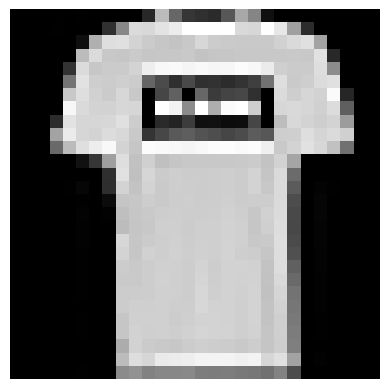

(28, 28)


In [4]:
import matplotlib.pyplot as plt
plt.figure()
image = X_train[1]
plt.imshow(X_train[1] ,cmap='gray' )
plt.axis('off')
plt.show()
print(image.shape)

### resizing and enhancing

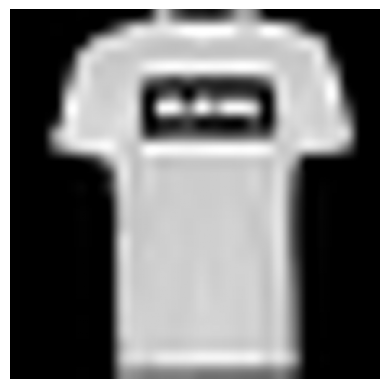

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageEnhance

train_sample = X_train[:100]
val_sample = X_test[:30]
img = train_sample[1]
# img = val_sample[1]

def resized(arr, size=256, sharpness=0):

    if arr.max() <= 1:
        arr = (arr * 255).astype(np.uint8)
    else:
        arr = arr.astype(np.uint8)

    img = Image.fromarray(arr)

    img = img.resize((size, size), Image.BICUBIC)

    enhancer = ImageEnhance.Sharpness(img)
    img = enhancer.enhance(sharpness)

    return np.array(img) / 255.0


image_resized = resized(img)
plt.imshow(image_resized, cmap='gray')
plt.axis('off')
plt.show()
plt.imsave("smooth0.png", image_resized, cmap='gray')


### creating dataset

In [6]:
import torch
from torch.utils.data import Dataset
import numpy as np
from torchvision import transforms
from noise_preprocess import simulate_qiup_hologram

class HologramDataset(Dataset):

    def __init__(self, root_dir: str):
        with open(root_dir, 'rb') as f:
            magic, num, rows, cols = np.frombuffer(f.read(16), dtype='>i4')
            data = np.frombuffer(f.read(), dtype=np.uint8)
            self.images = data.reshape(num, rows, cols)

        self.to_tensor = transforms.ToTensor()
        self.resize512 = transforms.Resize((512,512))
        self.resize256 = transforms.Resize((256,256))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img = self.images[idx]
        img = self.to_tensor(img)

        img_512 = self.resize512(img)

        holo = simulate_qiup_hologram(img_512)
        holo = transforms.functional.resize(holo, (512,512))

        gt = self.resize256(img_512)

        return gt, holo



In [10]:
train_path = f'data/MNIST/raw/train-images-idx3-ubyte'
myset = HologramDataset(train_path)
gt_sample = myset[0][0]
holo_sample = myset[0][1]

print(gt_sample.shape) , print(holo_sample.shape) 


torch.Size([1, 256, 256])
torch.Size([1, 512, 512])


(None, None)

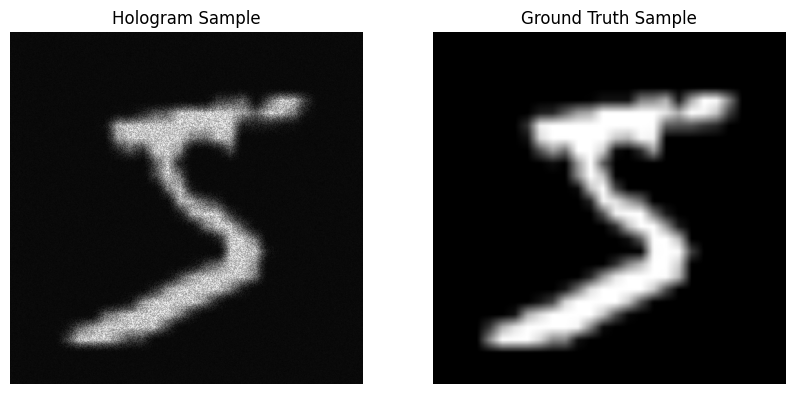

In [14]:
import matplotlib.pyplot as plt
import torch

train_path = f'data/MNIST/raw/train-images-idx3-ubyte'
myset = HologramDataset(train_path)
gt_sample = myset[0][0]
holo_sample = myset[0][1]

holo_img = holo_sample.squeeze().detach().cpu().numpy()
gt_img   = gt_sample.squeeze().detach().cpu().numpy()

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Hologram Sample")
plt.imshow(holo_img, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Ground Truth Sample")
plt.imshow(gt_img, cmap='gray')
plt.axis('off')

plt.show()


In [33]:
from torch.utils.data import random_split, ConcatDataset

datasets = ["MNIST", "FashionMNIST"]

mult_dataset_train = []
multi_dataset_test   = []

for name in datasets:

    train_path = rf"C:\Users\Ryan\Desktop\quantom_project\quantom_project\data\{name}\raw\train-images-idx3-ubyte"
    test_path = rf"C:\Users\Ryan\Desktop\quantom_project\quantom_project\data\{name}\raw\t10k-images-idx3-ubyte"

    train_dataset = HologramDataset(train_path)
    test_dataset  = HologramDataset(test_path)

    # i removed 5k imagse from test and added it to train , wanted more train than test
    test_size = len(test_dataset) // 2
    extra_train_size = len(test_dataset) - test_size

    test_subset, extra_train_subset = random_split(
        test_dataset,
        [test_size, extra_train_size]
    )
    train_dataset = ConcatDataset([train_dataset, extra_train_subset])
    mult_dataset_train.append(train_dataset)
    multi_dataset_test.append(test_subset)


In [38]:
len(mult_dataset_train) , len(multi_dataset_test) , len(mult_dataset_train[0]) , len(multi_dataset_test[1])

(2, 2, 65000, 5000)

### concating all trains and tests

In [37]:
from torch.utils.data import ConcatDataset 
train_data =ConcatDataset(mult_dataset_train)
test_data = ConcatDataset(multi_dataset_test)

len(train_data ) , len(test_data)

(130000, 10000)

### creating loader with batchsize and  picking 10 percent of data for validation

In [39]:
from torch.utils.data import random_split, DataLoader

train_size = int(0.9 * len(train_data))  
val_size   = len(train_data) - train_size  


train_dataset, val_dataset = random_split(train_data, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader   = DataLoader(test_data,   batch_size=4, shuffle=False)


In [40]:
len(train_loader) , len(val_loader)  , len(test_loader)

(29250, 3250, 2500)

In [41]:
for gt , holo  in train_loader: 
    print(gt.shape)  , print(holo.shape)
    break

torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 512, 512])


### initializing model

In [42]:
from torchinfo import summary
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model = Net(in_ch=1, out_ch=1).to(device)

# # Input size: (batch_size, channels, height, width)
# summary(model, input_size=(4, 4, 512, 512), col_names=["input_size", "output_size", "num_params"])


### starting training

In [ ]:
from tqdm import tqdm
from pytorch_msssim import ms_ssim

number_of_epoch = 3
criterion_mse = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters() , lr=0.001 ,  weight_decay=0.0005, amsgrad=True)


class NPCCLoss(nn.Module):
    def __init__(self):
        super(NPCCLoss, self).__init__()

    def forward(self, pred, target):
        B = pred.shape[0] # 4

        pred = pred.view(B, -1) # (4, 1*256*256)
        target = target.view(B, -1)#(4, 1 * 256*256)

        pred_mean = pred.mean(dim=1, keepdim=True) # (batch,1) 1 is mean
        target_mean = target.mean(dim=1, keepdim=True)

        pred_centered = pred - pred_mean # x-xpred
        target_centered = target - target_mean # y-ypred

        numerator = torch.sum(pred_centered * target_centered, dim=1) # covariance of x and y

        denominator = torch.sqrt( 
            torch.sum(pred_centered ** 2, dim=1) *
            torch.sum(target_centered ** 2, dim=1)
        )

        pcc = numerator / (denominator + 1e-8) # normalized covariance -1 to 1

        loss = -torch.mean(pcc) # [pcc1 , pcc2 .. pcc4] mean of all covariance 

        return loss


def ms_ssim_loss(pred, target):
    return 1 - ms_ssim(pred, target, data_range=1, size_average=True)

npcc_loss = NPCCLoss()

def calculate_loss(predict, gt): 
        loss_mse = criterion_mse(predict, gt)
        loss_npcc = npcc_loss(predict, gt)
        loss_ssim = ms_ssim_loss(predict, gt)
        loss = 4*loss_mse + loss_ssim + loss_npcc
        return loss

total_train_loss = []
total_val_loss = []
patience = 20
early_counter = 0 
best_loss = float('inf')

for epoch in tqdm(range(number_of_epoch)): 
    model.train()
    curr_train_loss = 0 
    for gt , noise in train_loader: 
        gt = gt.to(device)
        noise = noise.to(device)
        optimizer.zero_grad()
        predict = model(noise)
        loss = calculate_loss(predict, gt)
        loss.backward()
        optimizer.step()
        curr_train_loss += loss.item() 

    batch_loss = curr_train_loss / len(train_loader)
    total_train_loss.append(batch_loss)

    # validation part
    model.eval() 
    curr_val_loss = 0
    with torch.no_grad(): 
        for gt  , noise in val_loader : 
            gt = gt.to(device)
            noise = noise.to(device)
            val_predict = model(noise)
            loss = calculate_loss(val_predict, gt)
            curr_val_loss +=loss.item() 
        batch_val_loss = curr_val_loss / len(val_loader)
        total_val_loss.append(batch_val_loss)

        if batch_val_loss < best_loss : 
            best_loss = batch_val_loss 
            early_counter = 0
            torch.save({
                'state_dict' : model.state_dict(),
                'optimizer' : optimizer.state_dict(),
                'epoch' : epoch
            } , 'checkpoint/model_info.pth')
        else: 
            early_counter+=1
        if early_counter >= patience : 
            break




## saving test loss + images

In [ ]:
import torch
import os
from torchvision.utils import save_image

test_loss = []
gt_images = []
pred_images = []
max_save = 8  

save_dir = "test_results"
os.makedirs(save_dir, exist_ok=True)

model.eval()

with torch.no_grad():
    current_test_loss = 0
    saved = 0

    for i, (gt, noise) in enumerate(test_loader):

        gt = gt.to(device)
        noise = noise.to(device)

        predict = model(noise)

        loss = calculate_loss(predict, gt)
        current_test_loss += loss.item()

        if saved < max_save:
            gt_img = gt[0].cpu()
            pred_img = predict[0].cpu()

            save_image(gt_img, f"{save_dir}/gt_{saved}.png")
            save_image(pred_img, f"{save_dir}/pred_{saved}.png")

            saved += 1

    avg_loss = current_test_loss / len(test_loader)
    test_loss.append(avg_loss)


## saving test val and train loss numbers

In [ ]:
import pickle 
with open('checkpoint/loss.pkl' , 'wb') as f : 
    pickle.dump({
        'train_loss' : total_train_loss, 
        'val_loss' : total_val_loss,
        'test_loss' : test_loss
    }, f)

### visualizing train , val , test loss

In [ ]:
import pickle

with open('checkpoint/loss.pkl', 'rb') as f:
    data = pickle.load(f)

train_loss = data['train_loss']
val_loss   = data['val_loss']
test_loss  = data['test_loss']

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')



plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train / Validation / Test Loss Curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## visualizing predicted image with their gt

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(10,5))

for i in range(4):

    # GT
    axes[0, i].imshow(gt_images[i].squeeze(), cmap='gray')
    axes[0, i].set_title("GT")
    axes[0, i].axis("off")

    # Prediction
    axes[1, i].imshow(pred_images[i].squeeze(), cmap='gray')
    axes[1, i].set_title("Prediction")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


## fine tunning

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = Net(in_ch=1, out_ch=1).to(device)

model_info = torch.load(
    'checkpoint/model_info.pth',
    map_location=device
)

model.load_state_dict(model_info['state_dict'])

In [ ]:
for name, param in model.named_parameters():
    print(f"{name:50}  requires_grad = {param.requires_grad}")


In [ ]:
for param in model.CP.parameters():
    param.requires_grad = False

for param in model.Aspp1.parameters():
    param.requires_grad = False

for param in model.Aspp2.parameters():
    param.requires_grad = False

for param in model.Aspp3.parameters():
    param.requires_grad = False

for param in model.Aspp4.parameters():
    param.requires_grad = False

for param in model.Aspp5.parameters():
    param.requires_grad = False


In [ ]:
optimizer = torch.optim.AdamW(
    filter(lambda p:p.requires_grad , model.parameters()),
    lr= 1e-4, 
    weight_decay = 0.0005
)

### retrain with new freezed encoder and new optimizer

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

def enable_mc_dropout(model):

    for m in model.modules():

        if isinstance(m, nn.Dropout) or isinstance(m, nn.Dropout2d):
            m.train()

mc_runs = 30

model.eval()
enable_mc_dropout(model)

sample_gt, sample_noise = next(iter(test_loader))

sample_gt = sample_gt.to(device)
sample_noise = sample_noise.to(device)

predictions = []
with torch.no_grad():

    for _ in range(mc_runs):

        pred = model(sample_noise)

        predictions.append(pred.cpu())

predictions = torch.stack(predictions)

mean_prediction = predictions.mean(dim=0)

uncertainty_map = predictions.std(dim=0)

error_map = torch.abs(
    mean_prediction.cpu() - sample_gt.cpu()
)

hallucination_map = uncertainty_map * error_map

uncertainty_score = uncertainty_map.mean().item()

error_score = error_map.mean().item()

hallucination_score = hallucination_map.mean().item()

print(f"Uncertainty Score  : {uncertainty_score:.6f}")
print(f"Reconstruction Err : {error_score:.6f}")
print(f"Hallucination Score: {hallucination_score:.6f}")

gt_img = sample_gt[0].squeeze().cpu().numpy()

noise_img = sample_noise[0].squeeze().cpu().numpy()

pred_img = mean_prediction[0].squeeze().cpu().numpy()

uncertainty_img = uncertainty_map[0].squeeze().numpy()

error_img = error_map[0].squeeze().numpy()

hallucination_img = hallucination_map[0].squeeze().numpy()

fig, ax = plt.subplots(1, 6, figsize=(24, 5))

ax[0].imshow(noise_img, cmap='gray')
ax[0].set_title("Input")
ax[0].axis("off")

ax[1].imshow(pred_img, cmap='gray')
ax[1].set_title("Prediction")
ax[1].axis("off")

ax[2].imshow(gt_img, cmap='gray')
ax[2].set_title("GT")
ax[2].axis("off")

im1 = ax[3].imshow(uncertainty_img, cmap='hot')
ax[3].set_title("Uncertainty")
ax[3].axis("off")

im2 = ax[4].imshow(error_img, cmap='hot')
ax[4].set_title("Error")
ax[4].axis("off")

im3 = ax[5].imshow(hallucination_img, cmap='hot')
ax[5].set_title("Hallucination")
ax[5].axis("off")

plt.colorbar(im1, ax=ax[3], fraction=0.046)
plt.colorbar(im2, ax=ax[4], fraction=0.046)
plt.colorbar(im3, ax=ax[5], fraction=0.046)

plt.tight_layout()
plt.show()